In [1]:
import tensorflow as tf
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
(xtrain, ytrain),(xtest,ytest) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


8


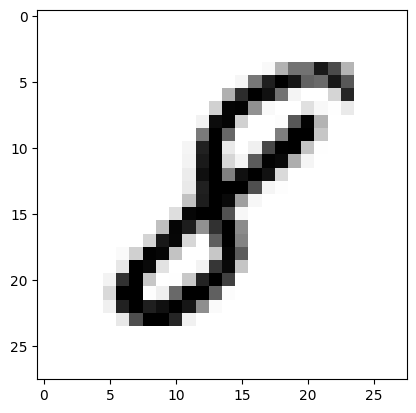

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
image_index = 7777
print(ytrain[image_index])
plt.imshow(xtrain[image_index],cmap= 'Greys')

In [3]:
xtrain.shape

(60000, 28, 28)

In [4]:
xtrain = xtrain.reshape(xtrain.shape[0], 28, 28, 1)
xtest = xtest.reshape(xtest.shape[0], 28,28,1)
input_shape = (28,28,1)

xtrain = xtrain.astype('float32')
xtest = xtest.astype('float32')

xtrain /= 255
xtest /= 255

print('x_train Shape:', xtrain.shape)
print('Number of images in x_train', xtrain.shape[0])
print('Number of images in x_test', xtest.shape[0])

x_train Shape: (60000, 28, 28, 1)
Number of images in x_train 60000
Number of images in x_test 10000


In [5]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D, Dropout, Flatten, MaxPooling2D

model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape = input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10, activation= tf.nn.softmax))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x = xtrain, y = ytrain, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9377 - loss: 0.2073
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9742 - loss: 0.0855
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9809 - loss: 0.0595
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9856 - loss: 0.0452
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9872 - loss: 0.0381
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9906 - loss: 0.0288
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9909 - loss: 0.0268
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9926 - loss: 0.0217
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9926 - loss: 0.0204
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9933 - loss: 0.0181


In [7]:
model.evaluate(xtest, ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9852 - loss: 0.0630


[0.06299486011266708, 0.9851999878883362]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
9


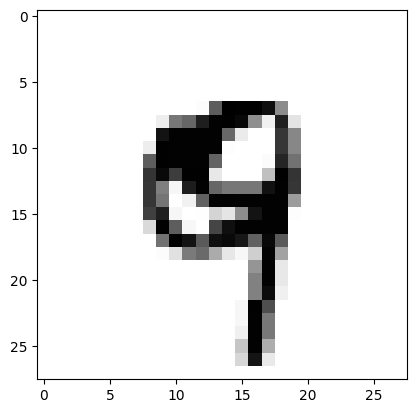

In [12]:
image_index = 4444
plt.imshow(xtest[image_index].reshape(28,28), cmap = 'Greys')
pred = model.predict(xtest[image_index].reshape(1,28,28,1))
print(pred.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
The no is: 1


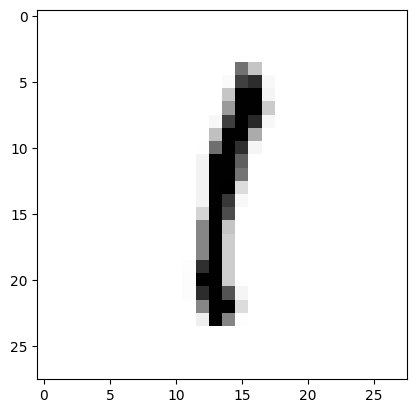

In [10]:
image_index = 3625
plt.imshow(xtest[image_index].reshape(28,28), cmap = 'Greys')
pred = model.predict(xtest[image_index].reshape(1,28,28,1))
print("The no is:", pred.argmax())